# 03 Gamma Forecast Impact

**Research question.** How much do RPF sign errors, and their correction by
`m9_pbm`, change direct seven-day-ahead net-load point forecasts?

Gamma is **Beta substation B**. It was selected because it has the largest
raw-versus-manual data-error RMSE and a practically material correction effect;
it is not described as the substation with the most RPF days. The notebook
creates three real data conditions, trains three forecast models, evaluates
September 2024, and writes publication-ready outputs. No synthetic, smoke-only,
or placeholder metric rows are permitted.

**Inputs:** final Gamma data, the cached unlabeled Beta-B candidate features,
and the Beta-B outer-fold `m9_pbm` artifact from Notebook 02e.  
**Outputs:** corrected Gamma series, forecast audits, two metric tables, four
figures, and one reproducibility manifest.  
**Expected runtime:** about two to five minutes after Notebook 02b exists.

## 1. Imports, Paths, And Visible Configuration

The path search works from JupyterLab, VS Code, or the repository root. The
displayed horizon, lookback, test month, and XGBoost settings are the complete
forecast contract used below.

In [1]:
from pathlib import Path
import sys
import time

import pandas as pd
from IPython.display import Image, display


def find_notebook_directory() -> Path:
    for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if candidate.name == "notebooks" and (candidate / "_gamma_forecast.py").exists():
            return candidate
        nested = candidate / "publication" / "2_journal_article" / "notebooks"
        if (nested / "_gamma_forecast.py").exists():
            return nested
    raise FileNotFoundError("Could not locate the journal notebook directory.")


NOTEBOOK_DIR = find_notebook_directory()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from _gamma_forecast import (  # noqa: E402
    CONDITION_COLUMNS,
    apply_m9_pbm_correction,
    build_forecast_examples,
    fit_direct_forecasts,
    forecast_impact_table,
    forecast_metric_rows,
    gamma_data_error_metrics,
    load_beta_b_model,
)
from _m9_pbm_data import (  # noqa: E402
    artifact_inventory,
    load_dataset,
    load_experiment_config,
    manifest_payload,
    output_dirs,
    resolve_paths,
    validate_input_hashes,
    write_csv,
    write_manifest,
    write_parquet,
)
from _m9_pbm_plotting import (  # noqa: E402
    plot_gamma_data_error,
    plot_gamma_example_week,
    plot_gamma_forecast_residuals,
    plot_gamma_forecast_rmse,
)

STARTED_AT = time.time()
ARTICLE_ROOT = NOTEBOOK_DIR.parent
CONFIG = load_experiment_config(ARTICLE_ROOT)
PATHS = resolve_paths(ARTICLE_ROOT, CONFIG)
SLUG = "03_gamma_forecast_impact"
OUTPUT_DIRS = output_dirs(PATHS, SLUG)

display(pd.Series(CONFIG["forecast"], name="forecast_configuration"))
display(pd.Series(CONFIG["windows"], name="experiment_windows"))

horizon_days                                                      7
lookback_days                                                    14
roll_frequency                                                15min
models                 [seasonal_naive, linear_regression, xgboost]
xgboost           {'objective': 'reg:squarederror', 'tree_method...
Name: forecast_configuration, dtype: object

train_start                  2021-11-01
train_end                    2023-09-30
test_start                   2023-10-01
test_end                     2024-09-30
beta_start                   2023-10-01
beta_end                     2024-09-30
gamma_forecast_test_start    2024-09-01
gamma_forecast_test_end      2024-09-30
Name: experiment_windows, dtype: object

## 2. Inputs And Leakage Audit

The correction artifact was produced when Beta B was the **outer held-out
substation**. It was trained and tuned using sure-labelled days from Beta
substations A, C, D, E, F, G, and H. Alpha and Beta-B labels were both excluded.
The candidate cache contains physical features only; labels are joined later
solely to construct the manual reference and evaluate the result.

In [2]:
GAMMA_PATH = PATHS.final_data / "dataset_gamma.parquet"
CANDIDATE_PATH = (
    PATHS.intermediate
    / "02b_m9_pbm_candidate_features"
    / "_partitions"
    / "beta_beta_B_candidates.parquet"
)
MODEL_PATH = PATHS.manifests / "02e_m9_pbm_beta_B_outer_fold_model.json"

hash_audit = validate_input_hashes(PATHS, CONFIG)
gamma = load_dataset("gamma", article_root=ARTICLE_ROOT, config=CONFIG)
model = load_beta_b_model(MODEL_PATH)
candidates = pd.read_parquet(CANDIDATE_PATH)

assert gamma["substation_id"].unique().tolist() == ["beta_B"]
assert gamma.groupby("date").size().eq(96).all()
assert candidates["date"].nunique() == gamma["date"].nunique() == 366
assert not {"label_day", "label_interval", "confidence"}.intersection(candidates.columns)

leakage_audit = pd.Series(
    {
        "heldout_substation": model["heldout_substation"],
        "training_substations": ", ".join(model["training_substations"]),
        "heldout_labels_used": model["heldout_labels_used"],
        "alpha_used": model["alpha_used"],
        "candidate_days": candidates["date"].nunique(),
        "gamma_intervals": len(gamma),
    },
    name="leakage_audit",
)
display(hash_audit)
display(leakage_audit)

,filename,expected_sha256,actual_sha256,matches
0,dataset_alpha.parquet,c2d0982d138a1faebd30df60b7fd861c73007b5709187a...,c2d0982d138a1faebd30df60b7fd861c73007b5709187a...,True
1,dataset_beta.parquet,e1971eff266de145c4aca79ce5272541afee5861d18874...,e1971eff266de145c4aca79ce5272541afee5861d18874...,True
2,dataset_gamma.parquet,7ebeedeab63b1a95059c0f413744230a183bf1d6f6883f...,7ebeedeab63b1a95059c0f413744230a183bf1d6f6883f...,True


heldout_substation                                                 beta_B
training_substations    beta_A, beta_C, beta_D, beta_E, beta_F, beta_G...
heldout_labels_used                                                 False
alpha_used                                                          False
candidate_days                                                        366
gamma_intervals                                                     35136
Name: leakage_audit, dtype: object

## 3. Three Gamma Data Conditions

For each quarter-hour $t$, the observed raw net load is $y(t)$. The physical
model selects one candidate window per day and predicts a day only when its
weighted score reaches the fixed Beta-B threshold:

\[
s(W)=w_1F_1(W)+w_3F_3(W)+w_4F_4(W),
\qquad
\widehat d=\mathbf 1\{\max_W s(W)\ge\tau\}.
\]

The model-corrected and manually corrected series are

\[
x_{m9}(t)=
\begin{cases}
-y(t), & \widehat d=1 \text{ and }t\in\widehat W,\\
y(t), & \text{otherwise},
\end{cases}
\qquad
x_{manual}(t)=
\begin{cases}
-y(t), & z(t)=1,\\
y(t), & z(t)=0.
\end{cases}
\]

**Notation.** $W$ is a candidate window; $F_1,F_3,F_4$ are bridge,
slope-continuity, and duration scores; $w_1,w_3,w_4$ are fixed fitted weights;
$\tau$ is the fixed threshold; $\widehat W$ is the highest-scoring window;
$\widehat d$ is the model's day decision; and $z(t)$ is the final manual
interval label. Crucially, $z(t)$ does not enter the `m9_pbm` score or decision.

In [3]:
SERIES_PATH = OUTPUT_DIRS["intermediate"] / "01_gamma_series.parquet"
DATA_ERROR_PATH = OUTPUT_DIRS["metrics"] / "01_gamma_data_error_metrics.csv"
DATA_ERROR_TABLE = OUTPUT_DIRS["tables"] / "table01_gamma_data_error_summary.csv"

gamma_series, m9_day_predictions = apply_m9_pbm_correction(
    gamma,
    candidates,
    model,
)
data_error_metrics = gamma_data_error_metrics(
    gamma_series,
    test_start=CONFIG["windows"]["gamma_forecast_test_start"],
    test_end=CONFIG["windows"]["gamma_forecast_test_end"],
)
write_parquet(gamma_series, SERIES_PATH)
write_csv(data_error_metrics, DATA_ERROR_PATH)
write_csv(data_error_metrics, DATA_ERROR_TABLE)

display(pd.Series(model["weights"], name="fixed_Beta_B_weights"))
print(f"Fixed threshold: {model['threshold']:.6f}")
display(data_error_metrics)

F1_bridge_improvement              0.454408
F3_slope_continuity_improvement    0.171672
F4_duration_plausibility           0.373921
Name: fixed_Beta_B_weights, dtype: float64

Fixed threshold: 0.674593


,scope,data_condition,data_condition_label,n_valid,rmse_MW,mae_MW,rmse_reduction_vs_raw_MW,mae_reduction_vs_raw_MW,rmse_reduction_vs_raw_pct,mae_reduction_vs_raw_pct
0,full_gamma,raw_uncorrected,Raw uncorrected,34893,2.266361,0.611978,0.000000,0.000000,0.000000,0.000000
1,full_gamma,m9_pbm_corrected,m9_pbm corrected,34893,1.273362,0.244072,0.992999,0.367906,43.814684,60.117505
2,forecast_test_month,raw_uncorrected,Raw uncorrected,2876,4.765054,2.007530,0.000000,0.000000,0.000000,0.000000
3,forecast_test_month,m9_pbm_corrected,m9_pbm corrected,2876,1.326066,0.234226,3.438988,1.773304,72.171026,88.332615


## 4. Direct Seven-Day-Ahead Forecast Design

Each row is one point forecast, not one element of a seven-day trajectory from
a common origin. For every September target $t$, the origin is exactly
$o=t-7\text{ days}$, and the predictor is

\[
\widehat x(t\mid o)=f_\theta\left(\mathcal H_{14}(o),c(t)\right).
\]

**Notation.** $t$ is one 15-minute target timestamp; $o$ is its forecast
origin; $\mathcal H_{14}(o)$ is the 14-day history ending at $o$; $c(t)$
contains only calendar values known for the target; $f_\theta$ is seasonal
naive, linear regression, or XGBoost; and $\theta$ denotes parameters fitted
once using target examples ending before September. No feature observes a value after $o$, and
the learned models are not refitted during September.

The 14-day history is represented by the same-quarter-hour values at the origin
and preceding 13 days, robust whole-window summaries, last-day summaries, and
the count of finite readings. Calendar features use cyclic time-of-day,
day-of-week, and month terms plus a weekend indicator.

In [4]:
TEST_START = CONFIG["windows"]["gamma_forecast_test_start"]
TEST_END = CONFIG["windows"]["gamma_forecast_test_end"]
TRAIN_START = gamma_series["timestamp"].min().strftime("%Y-%m-%d")
TRAIN_END = (pd.Timestamp(TEST_START) - pd.Timedelta(minutes=15)).strftime("%Y-%m-%d")
HORIZON_DAYS = int(CONFIG["forecast"]["horizon_days"])
LOOKBACK_DAYS = int(CONFIG["forecast"]["lookback_days"])

train_examples = {}
test_examples = {}
matrix_paths = []
for condition, column in CONDITION_COLUMNS.items():
    train = build_forecast_examples(
        gamma_series,
        column,
        target_start=TRAIN_START,
        target_end=TRAIN_END,
        horizon_days=HORIZON_DAYS,
        lookback_days=LOOKBACK_DAYS,
    )
    test = build_forecast_examples(
        gamma_series,
        column,
        target_start=TEST_START,
        target_end=TEST_END,
        horizon_days=HORIZON_DAYS,
        lookback_days=LOOKBACK_DAYS,
    )
    assert train["target_timestamp"].max() < pd.Timestamp(TEST_START, tz="UTC")
    assert test["target_timestamp"].sub(test["origin_timestamp"]).eq(
        pd.Timedelta(days=HORIZON_DAYS)
    ).all()
    train_examples[condition] = train
    test_examples[condition] = test
    train_path = OUTPUT_DIRS["intermediate"] / f"02_train_{condition}.parquet"
    test_path = OUTPUT_DIRS["intermediate"] / f"03_test_{condition}.parquet"
    write_parquet(train, train_path)
    write_parquet(test, test_path)
    matrix_paths.extend([train_path, test_path])

design_audit = pd.DataFrame(
    [
        {
            "data_condition": condition,
            "training_examples": len(train_examples[condition]),
            "training_target_end": train_examples[condition]["target_timestamp"].max(),
            "test_examples": len(test_examples[condition]),
            "test_origin_end": test_examples[condition]["origin_timestamp"].max(),
        }
        for condition in CONDITION_COLUMNS
    ]
)
display(design_audit)

,data_condition,training_examples,training_target_end,test_examples,test_origin_end
0,raw_uncorrected,30240,2024-08-31 23:45:00+00:00,2880,2024-09-23 23:45:00+00:00
1,m9_pbm_corrected,30240,2024-08-31 23:45:00+00:00,2880,2024-09-23 23:45:00+00:00
2,manually_corrected,30240,2024-08-31 23:45:00+00:00,2880,2024-09-23 23:45:00+00:00


## 5. Fit Once, Then Forecast September

Seasonal naive copies the value at the exact seven-day origin. Linear
regression standardises median-imputed physical-history features. XGBoost uses
the fixed configuration displayed in Section 1. Each learned model is fitted
once under each data condition. All predictions are evaluated against the
manually corrected target, so changing the training-data condition is the only
intended comparison.

In [5]:
prediction_frames = []
fit_audits = []
for condition in CONDITION_COLUMNS:
    condition_predictions, condition_audit = fit_direct_forecasts(
        train_examples[condition],
        test_examples[condition],
        data_condition=condition,
        config=CONFIG,
    )
    prediction_frames.append(condition_predictions)
    fit_audits.append(condition_audit)

forecast_predictions = pd.concat(prediction_frames, ignore_index=True)
fit_audit = pd.concat(fit_audits, ignore_index=True)
PREDICTION_PATH = OUTPUT_DIRS["intermediate"] / "04_gamma_forecast_predictions.parquet"
FIT_AUDIT_PATH = OUTPUT_DIRS["intermediate"] / "05_forecast_fit_audit.csv"
write_parquet(forecast_predictions, PREDICTION_PATH)
write_csv(fit_audit, FIT_AUDIT_PATH)

assert forecast_predictions["status"].eq("complete").all()
assert not forecast_predictions["is_placeholder"].any()
assert fit_audit["fit_count_per_learned_model"].eq(1).all()
display(fit_audit)

,data_condition,training_examples,training_target_start,training_target_end,test_examples,test_target_start,test_target_end,fit_count_per_learned_model,maximum_test_observation_timestamp
0,raw_uncorrected,30006,2023-10-22 00:00:00+00:00,2024-08-31 23:45:00+00:00,2880,2024-09-01 00:00:00+00:00,2024-09-30 23:45:00+00:00,1,2024-09-23 23:45:00+00:00
1,m9_pbm_corrected,30006,2023-10-22 00:00:00+00:00,2024-08-31 23:45:00+00:00,2880,2024-09-01 00:00:00+00:00,2024-09-30 23:45:00+00:00,1,2024-09-23 23:45:00+00:00
2,manually_corrected,30006,2023-10-22 00:00:00+00:00,2024-08-31 23:45:00+00:00,2880,2024-09-01 00:00:00+00:00,2024-09-30 23:45:00+00:00,1,2024-09-23 23:45:00+00:00


## 6. Forecast Metrics And Impact

RMSE and MAE use every target for which both the prediction and manually
corrected reference are finite. The valid-target count is displayed rather
than silently treating missing measurements as zero. The impact table reports
the RMSE change from raw to `m9_pbm`-corrected training data for each model and
shows the remaining distance to the ideal manually corrected condition.

In [6]:
FORECAST_METRICS_PATH = OUTPUT_DIRS["metrics"] / "02_gamma_forecast_metrics.csv"
FORECAST_TABLE = OUTPUT_DIRS["tables"] / "table02_gamma_forecast_impact.csv"

forecast_metrics = forecast_metric_rows(forecast_predictions)
impact = forecast_impact_table(forecast_metrics)
write_csv(forecast_metrics, FORECAST_METRICS_PATH)
write_csv(impact, FORECAST_TABLE)
display(forecast_metrics)
display(impact)

,data_condition,data_condition_label,model,model_label,n_targets_total,n_valid,rmse_MW,mae_MW,status,is_placeholder
0,m9_pbm_corrected,m9_pbm corrected,linear_regression,Linear regression,2880,2876,3.136560,2.045310,complete,False
1,manually_corrected,Manually corrected,linear_regression,Linear regression,2880,2876,3.068551,1.968393,complete,False
2,raw_uncorrected,Raw uncorrected,linear_regression,Linear regression,2880,2876,4.716050,2.745357,complete,False
3,m9_pbm_corrected,m9_pbm corrected,seasonal_naive,Seasonal naive,2880,2871,3.814947,2.107219,complete,False
4,manually_corrected,Manually corrected,seasonal_naive,Seasonal naive,2880,2871,3.666964,2.005492,complete,False
5,raw_uncorrected,Raw uncorrected,seasonal_naive,Seasonal naive,2880,2871,4.808066,2.820274,complete,False
6,m9_pbm_corrected,m9_pbm corrected,xgboost,XGBoost,2880,2876,4.023179,2.722851,complete,False
7,manually_corrected,Manually corrected,xgboost,XGBoost,2880,2876,2.636279,1.727513,complete,False
8,raw_uncorrected,Raw uncorrected,xgboost,XGBoost,2880,2876,4.424878,2.605359,complete,False


,model,model_label,raw_rmse_MW,m9_pbm_corrected_rmse_MW,manually_corrected_rmse_MW,m9_rmse_reduction_vs_raw_MW,m9_rmse_reduction_vs_raw_pct,remaining_gap_to_manual_rmse_MW
0,linear_regression,Linear regression,4.716050,3.136560,3.068551,1.579489,33.491787,0.068009
1,seasonal_naive,Seasonal naive,4.808066,3.814947,3.666964,0.993119,20.655275,0.147982
2,xgboost,XGBoost,4.424878,4.023179,2.636279,0.401699,9.078184,1.386900


## 7. Publication Figures

The weekly curve exposes where the correction acts. The remaining figures
separate data error from forecast error and show the residual distributions,
so an average RMSE difference is not the only evidence available.

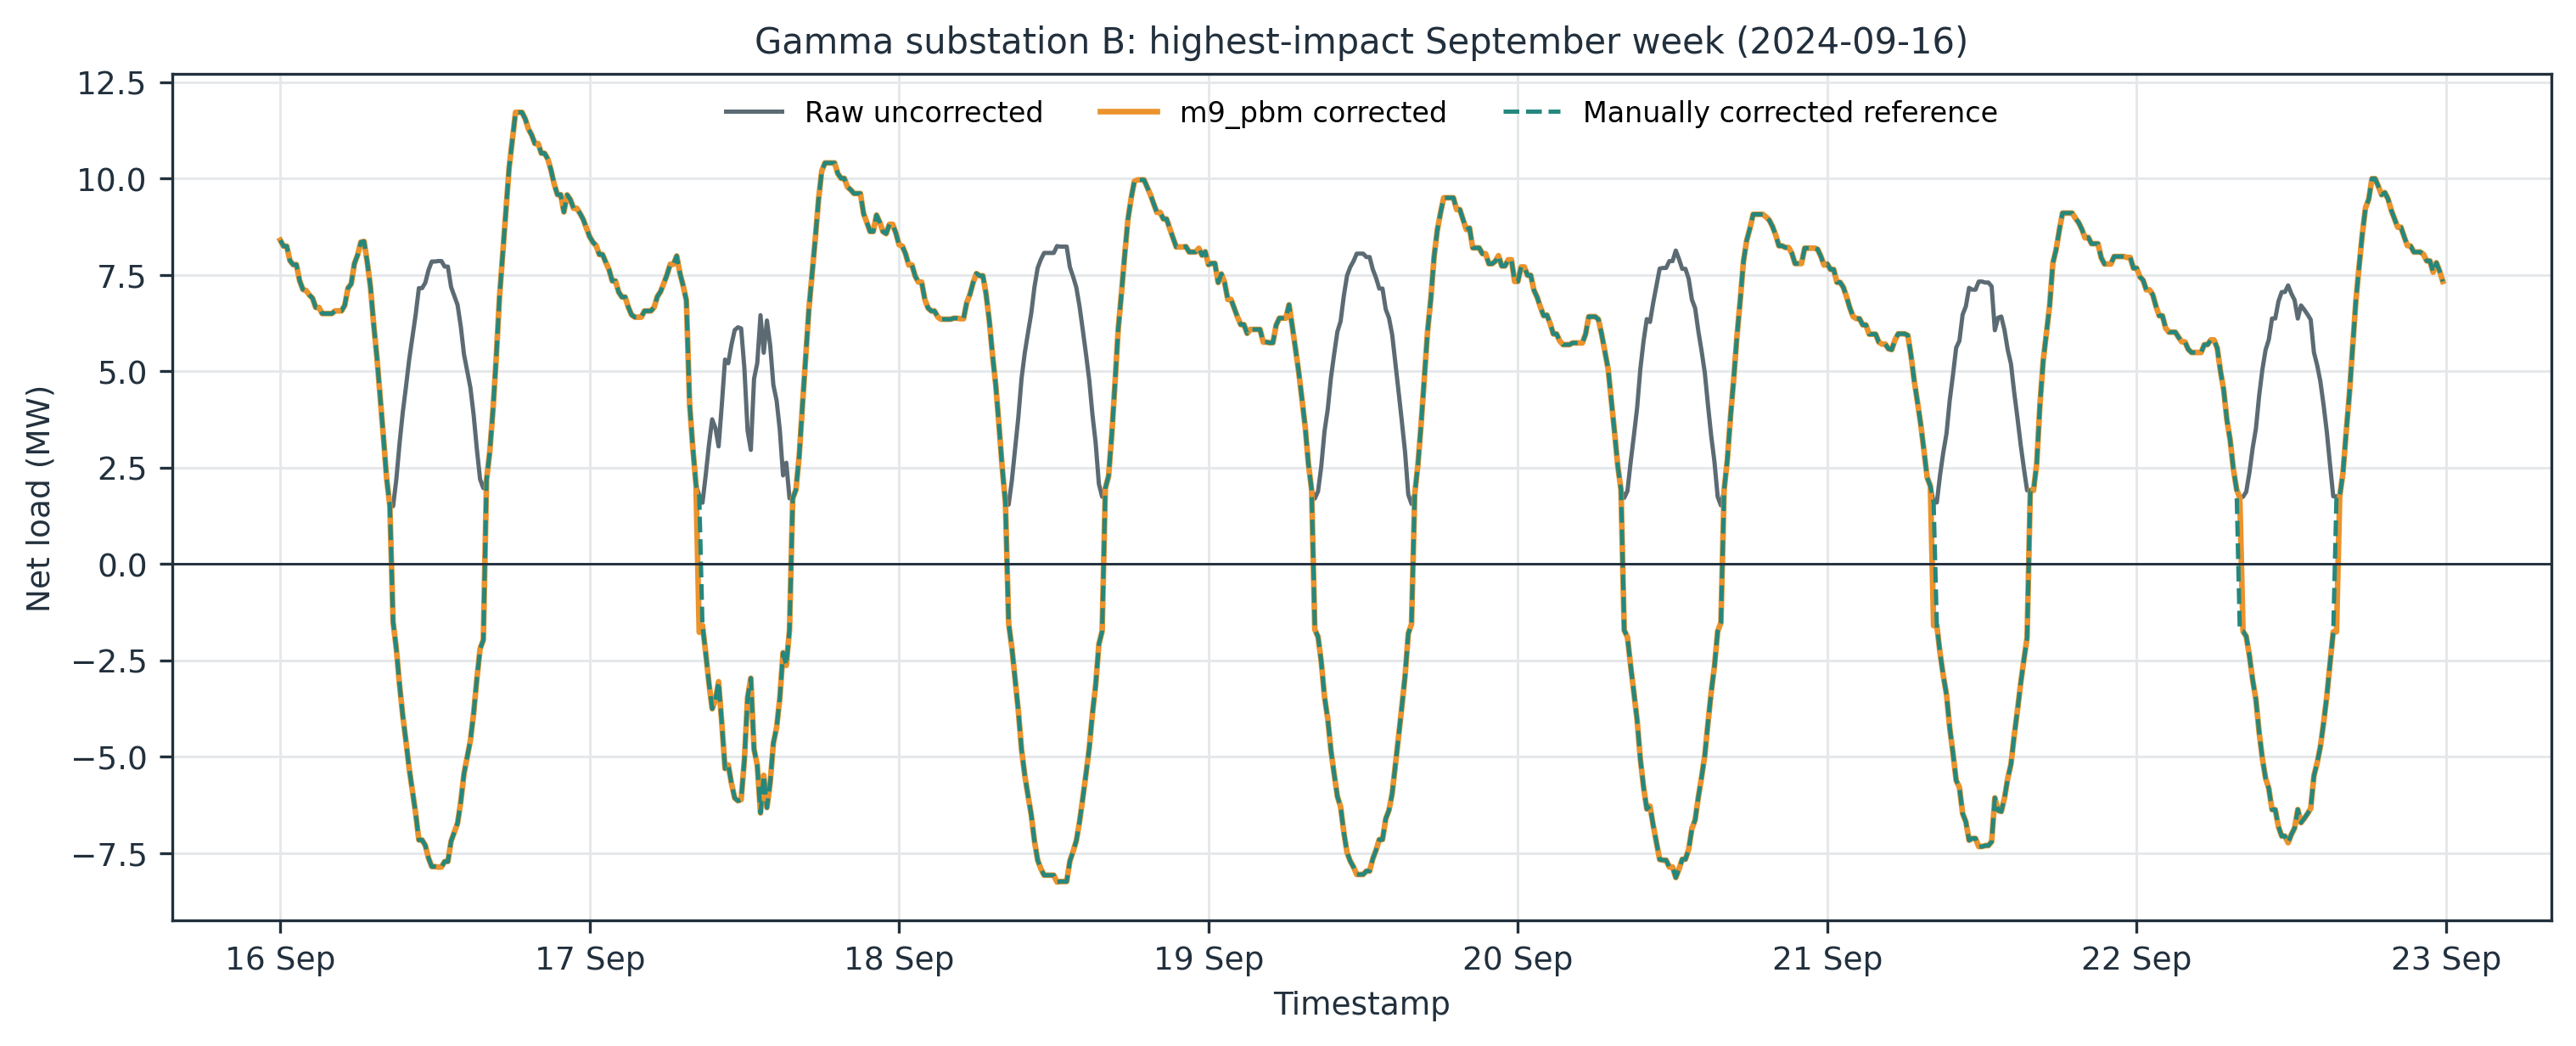

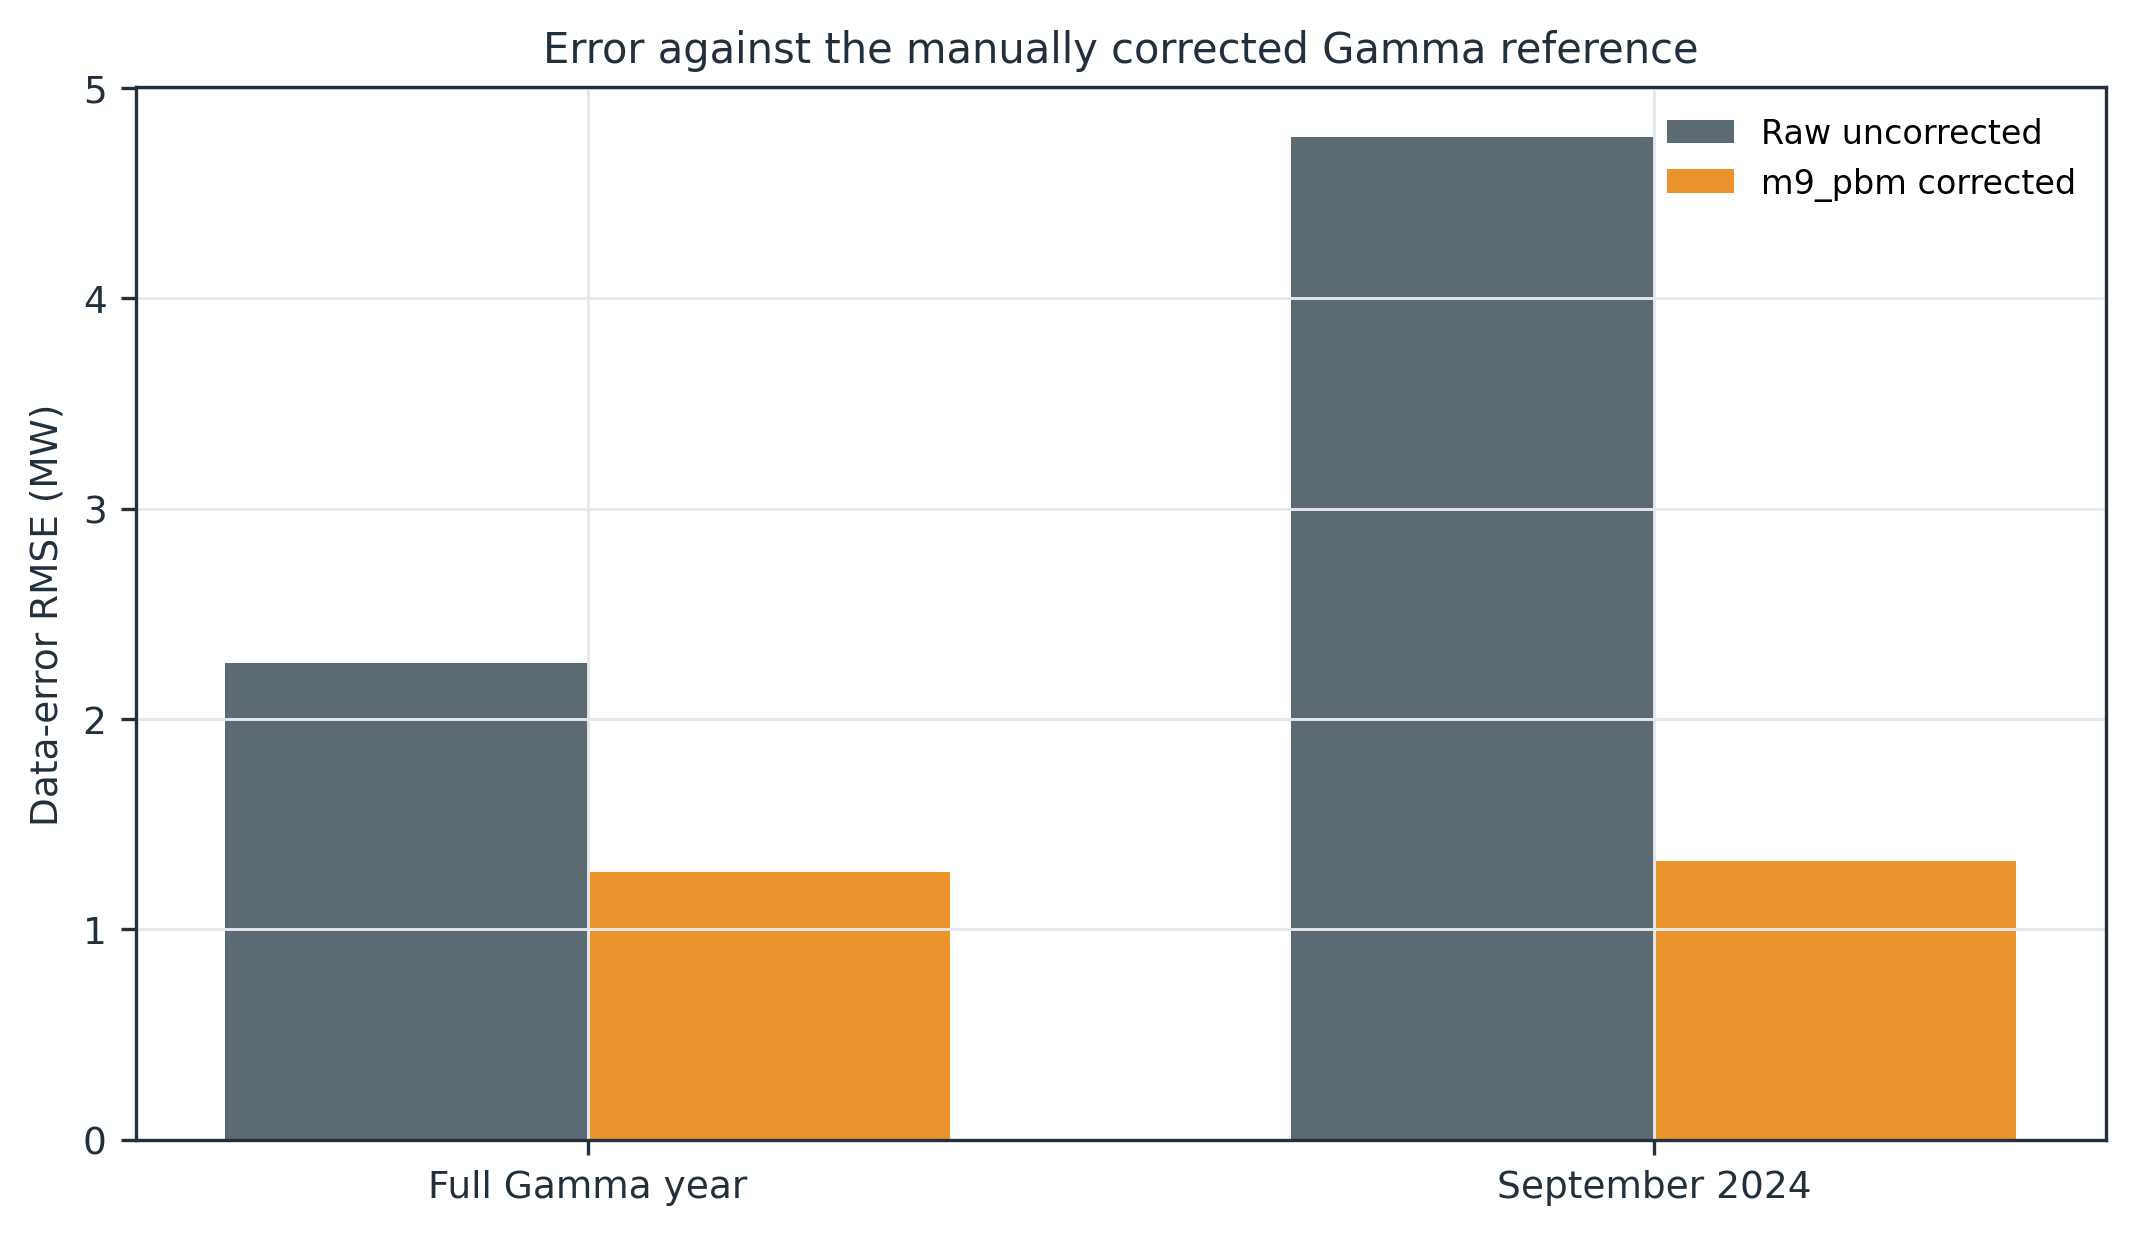

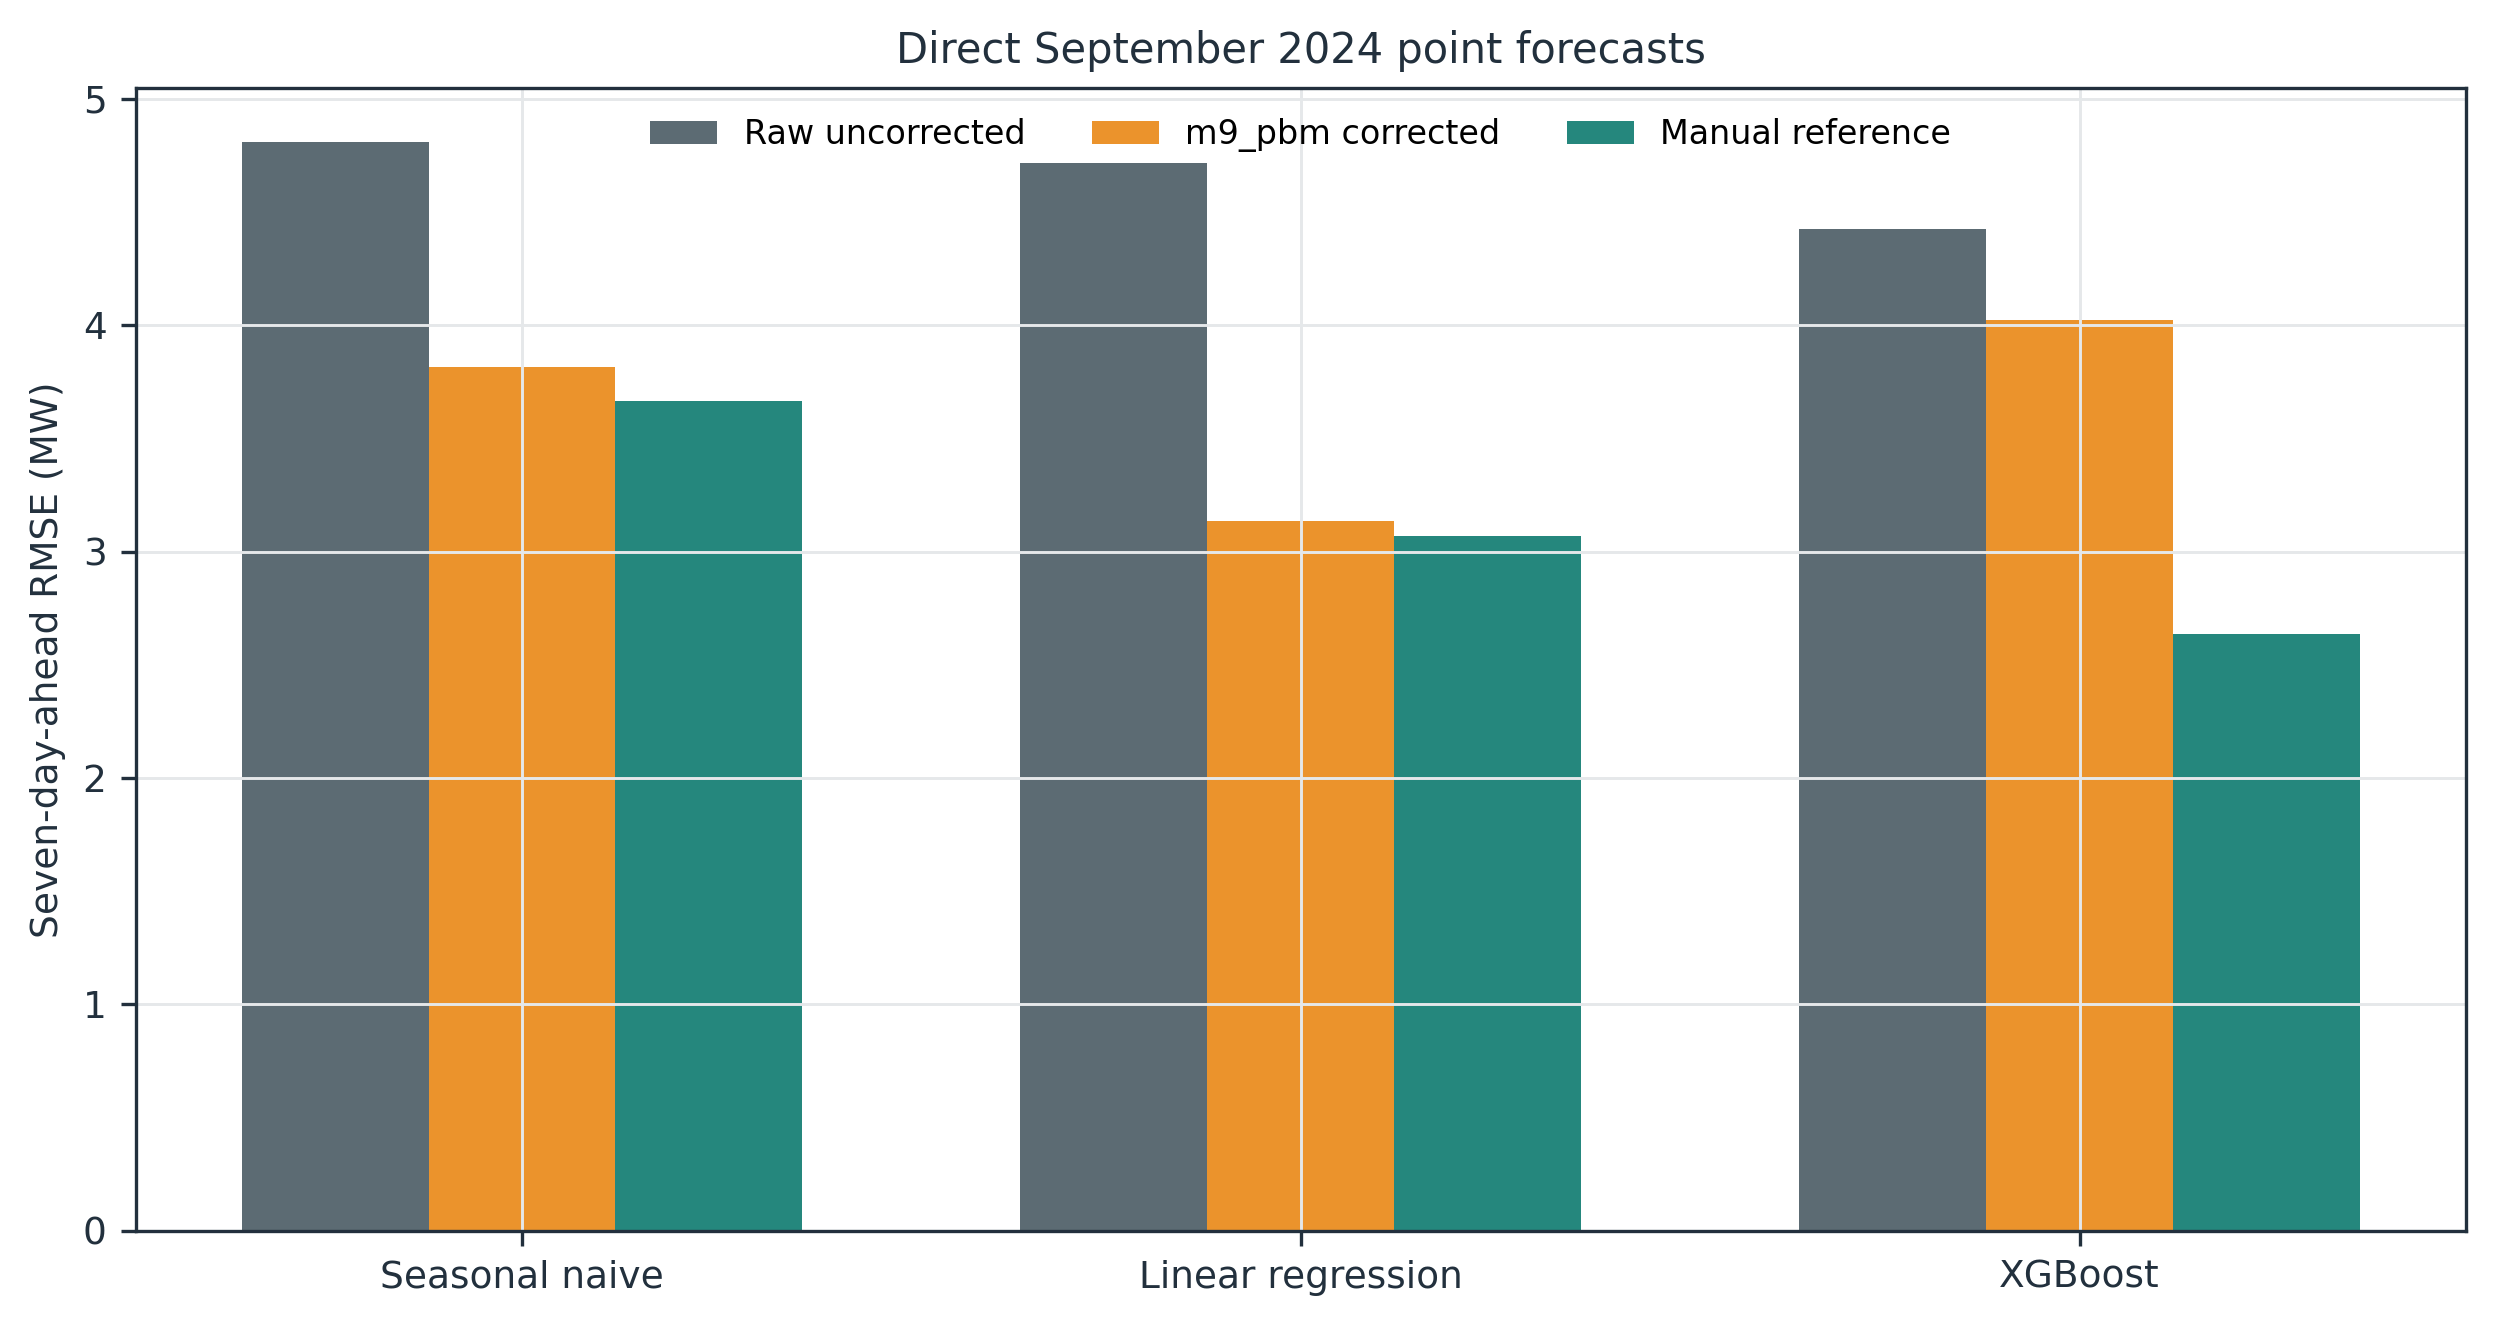

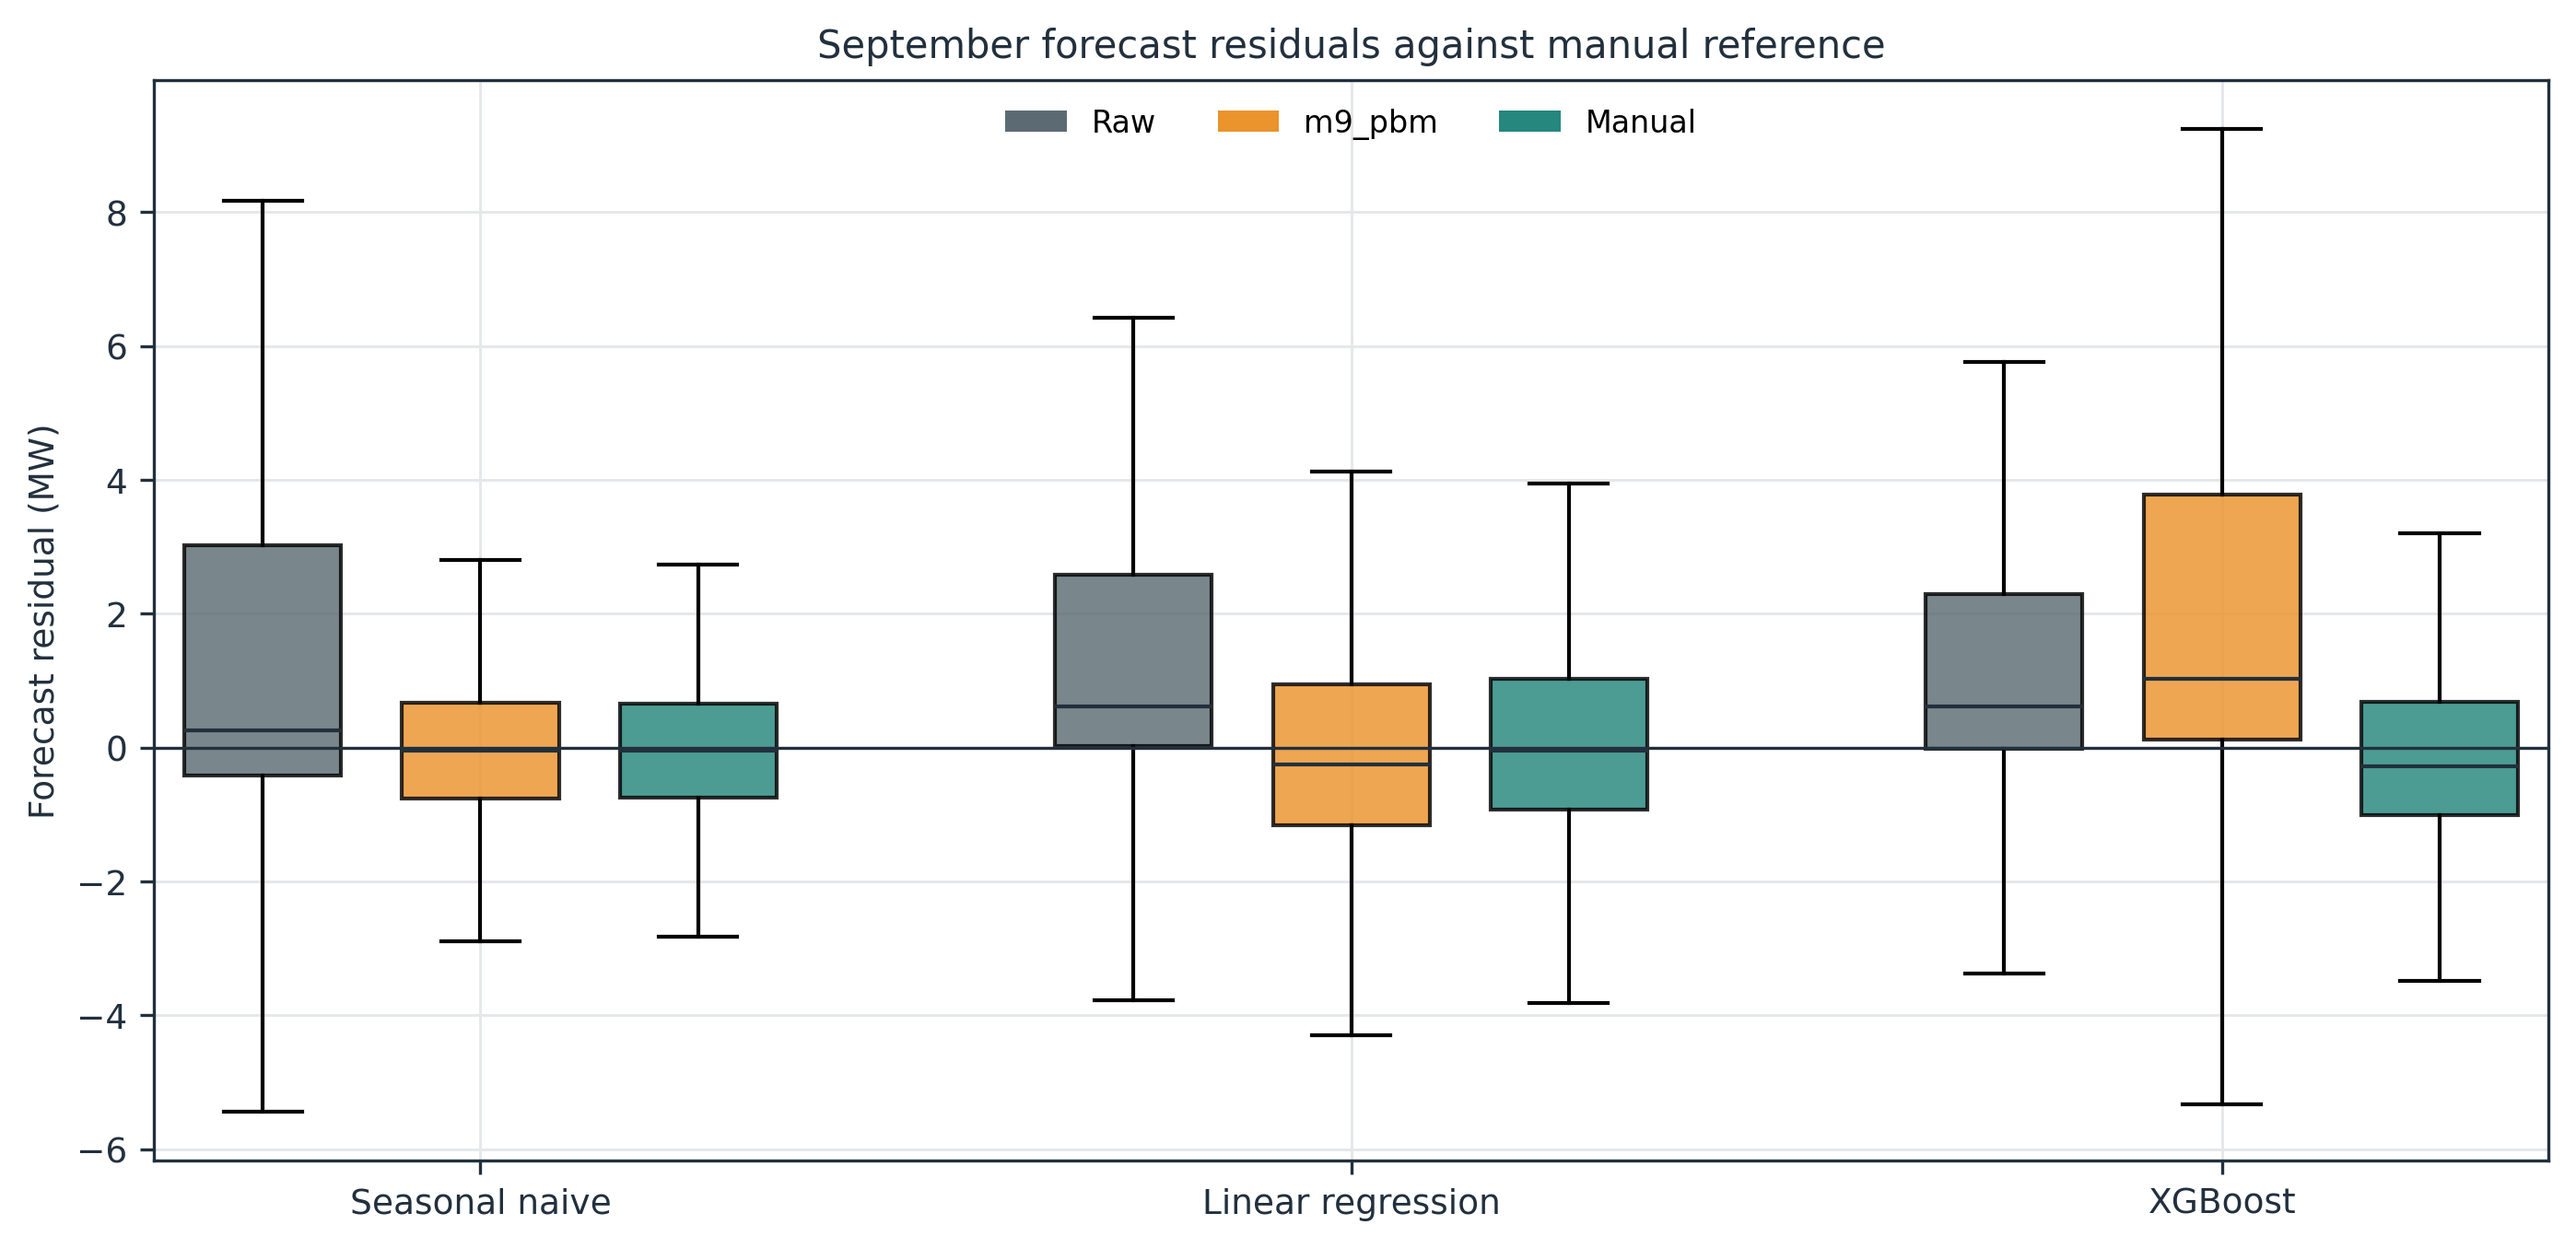

In [7]:
FIGURE_WEEK = OUTPUT_DIRS["figures"] / "fig01_gamma_raw_m9_manual_example_week.png"
FIGURE_DATA_ERROR = OUTPUT_DIRS["figures"] / "fig02_gamma_data_error_rmse.png"
FIGURE_FORECAST = OUTPUT_DIRS["figures"] / "fig03_gamma_forecast_rmse.png"
FIGURE_RESIDUAL = OUTPUT_DIRS["figures"] / "fig04_gamma_forecast_residuals.png"

plot_gamma_example_week(gamma_series, FIGURE_WEEK)
plot_gamma_data_error(data_error_metrics, FIGURE_DATA_ERROR)
plot_gamma_forecast_rmse(forecast_metrics, FIGURE_FORECAST)
plot_gamma_forecast_residuals(forecast_predictions, FIGURE_RESIDUAL)
for figure_path in [FIGURE_WEEK, FIGURE_DATA_ERROR, FIGURE_FORECAST, FIGURE_RESIDUAL]:
    display(Image(filename=figure_path))

## 8. Interpretation And Limitations

The code below prints the measured effects without assuming that correction
must improve every forecast model. This is a single-substation case study, and
the manually corrected series remains label-dependent. The Beta-B correction
is leakage-isolated with respect to labels and Alpha, but feature-family design
was informed by the wider Beta development process. Missing target readings
are excluded from metric denominators and are counted explicitly.

In [8]:
full_data = data_error_metrics.loc[data_error_metrics["scope"].eq("full_gamma")]
raw_data = full_data.loc[full_data["data_condition"].eq("raw_uncorrected")].iloc[0]
m9_data = full_data.loc[full_data["data_condition"].eq("m9_pbm_corrected")].iloc[0]
print(f"Full-year raw data-error RMSE: {raw_data['rmse_MW']:.3f} MW")
print(f"Full-year m9 data-error RMSE:  {m9_data['rmse_MW']:.3f} MW")
print(
    "Full-year RMSE reduction: "
    f"{m9_data['rmse_reduction_vs_raw_MW']:.3f} MW "
    f"({m9_data['rmse_reduction_vs_raw_pct']:.1f}%)"
)
display(impact[["model_label", "m9_rmse_reduction_vs_raw_MW", "m9_rmse_reduction_vs_raw_pct"]])

Full-year raw data-error RMSE: 2.266 MW
Full-year m9 data-error RMSE:  1.273 MW
Full-year RMSE reduction: 0.993 MW (43.8%)


,model_label,m9_rmse_reduction_vs_raw_MW,m9_rmse_reduction_vs_raw_pct
0,Linear regression,1.579489,33.491787
1,Seasonal naive,0.993119,20.655275
2,XGBoost,0.401699,9.078184


## 9. Reproducibility Manifest And Output Inventory

The manifest records all input hashes and output paths. The final assertions
fail if any declared artifact is missing, empty, placeholder, or inconsistent
with the fixed forecast design.

In [9]:
FINAL_OUTPUTS = [
    SERIES_PATH,
    DATA_ERROR_PATH,
    FORECAST_METRICS_PATH,
    DATA_ERROR_TABLE,
    FORECAST_TABLE,
    FIGURE_WEEK,
    FIGURE_DATA_ERROR,
    FIGURE_FORECAST,
    FIGURE_RESIDUAL,
]
manifest = manifest_payload(
    paths=PATHS,
    config=CONFIG,
    started_at=STARTED_AT,
    inputs=[PATHS.config, GAMMA_PATH, CANDIDATE_PATH, MODEL_PATH],
    outputs=FINAL_OUTPUTS,
    row_counts={
        "gamma_intervals": len(gamma_series),
        "gamma_days": gamma_series["date"].nunique(),
        "forecast_predictions": len(forecast_predictions),
        "valid_reference_targets": int(forecast_predictions["y_reference"].notna().sum()),
    },
)
manifest.update(
    {
        "status": "publication_ready",
        "gamma_substation": "beta_B",
        "contains_placeholder_forecasts": False,
        "correction_artifact": MODEL_PATH.name,
        "heldout_labels_used": False,
        "alpha_used": False,
        "forecast_models_fit_once_before_test_month": True,
        "local_intermediates": [
            str(path.relative_to(PATHS.article))
            for path in [*matrix_paths, PREDICTION_PATH, FIT_AUDIT_PATH]
        ],
    }
)
MANIFEST_PATH = write_manifest(PATHS, f"{SLUG}.json", manifest)
inventory = artifact_inventory(
    {path.name: path for path in [*FINAL_OUTPUTS, MANIFEST_PATH]},
    relative_to=PATHS.article,
)
display(inventory)
assert inventory["exists"].all() and inventory["bytes"].gt(0).all()

,artifact,path,exists,bytes
0,01_gamma_series.parquet,outputs/intermediate/03_gamma_forecast_impact/...,True,1841737
1,01_gamma_data_error_metrics.csv,outputs/metrics/03_gamma_forecast_impact/01_ga...,True,716
2,02_gamma_forecast_metrics.csv,outputs/metrics/03_gamma_forecast_impact/02_ga...,True,1241
3,table01_gamma_data_error_summary.csv,outputs/tables/03_gamma_forecast_impact/table0...,True,716
4,table02_gamma_forecast_impact.csv,outputs/tables/03_gamma_forecast_impact/table0...,True,592
5,fig01_gamma_raw_m9_manual_example_week.png,outputs/figures/03_gamma_forecast_impact/fig01...,True,358188
6,fig02_gamma_data_error_rmse.png,outputs/figures/03_gamma_forecast_impact/fig02...,True,70940
7,fig03_gamma_forecast_rmse.png,outputs/figures/03_gamma_forecast_impact/fig03...,True,82015
8,fig04_gamma_forecast_residuals.png,outputs/figures/03_gamma_forecast_impact/fig04...,True,87137
9,03_gamma_forecast_impact.json,outputs/manifests/03_gamma_forecast_impact.json,True,4230
